# Graph Analyze : clustering

```networkx``` documentation available [here](https://networkx.org/documentation/stable/reference/algorithms/index.html)

## 0 - Data Reading

In [81]:
import os
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from typing import Tuple, List, Dict, Any

import networkx as nx
from networkx.algorithms.community import louvain_communities, modularity
from sklearn.metrics import adjusted_rand_score
from itertools import combinations

full_dataset = "horoscope_full"
df = pd.read_csv(f'..\\data\\{full_dataset}.csv')
df.head()

input_method = 0
# 0 for MinHashing matrix
# 1 for Frequent Itemsets matrix
# 2 for Random graph
input_file_name = "similarity_love_lsh"  # MinHashing
# input_file_name = "shared_2_itemsets_pairs" # Frequent Itemsets
# !! be sure to set the correct input_file_name according to input_method !!

threshold = 0.3 # edges with weight below this value will be ignored

methods = [ # select the methods you want to run by commenting
    'louvain',
    # 'girvan_newman'
]

pre_visualization = False

## 1 - Graph Definition
### 
use of the ```networkx``` to generate a graph from the matrix of similarities

In [119]:
# ---------------------------------------------
#    horoscope-extracted graph - MinHashing
# ---------------------------------------------

def make_simmatrix_from_couples(
    df: pd.DataFrame,
    threshold: float = 1.0,
    id1_col: str = "ID1",
    id2_col: str = "ID2",
    sim_col: str = "similarity",
    scaling: bool = False,
    sort_ids: bool = True,
    dtype: Any = float,
) -> Tuple[sparse.csr_matrix, List[Any], Dict[Any, int]]:
    """
    Build a *compact* symmetric similarity matrix from a dataframe of pairs.

    Refactored: we no longer expand to the full numeric ID range with gaps.
    Only IDs that actually appear after threshold filtering are retained.
    This avoids huge, sparse matrices when original IDs are large row numbers.

    Returns
    -------
    S : csr_matrix (n_ids x n_ids)
        Symmetric similarity (weight) matrix.
    id_list : list
        Ordered list of actual node IDs present (no padding).
    id_to_index : dict
        Mapping original ID -> index in S.

    Parameters
    ----------
    df : DataFrame containing columns id1_col, id2_col, sim_col.
    threshold : keep only rows with similarity >= threshold.
    scaling : if True, min-max scale similarities before thresholding.
    sort_ids : attempt numeric sort else lexicographic.
    dtype : numeric dtype for stored similarities.

    Notes
    -----
    - Self-loops are stored once.
    - Symmetry enforced by adding (j,i) when i!=j.
    - NaNs in ID or similarity columns are skipped.
    """
    if id1_col not in df.columns or id2_col not in df.columns or sim_col not in df.columns:
        raise ValueError(f"DataFrame must contain {id1_col}, {id2_col}, {sim_col}")

    work = df.copy()

    if scaling:
        min_sim = work[sim_col].min(); max_sim = work[sim_col].max()
        if max_sim > min_sim:
            work[sim_col] = (work[sim_col] - min_sim) / (max_sim - min_sim)
        else:
            work[sim_col] = 1.0

    # Threshold filtering
    work = work[work[sim_col] >= threshold]

    # Collect IDs that actually appear after filtering
    ids = pd.Index(work[id1_col].dropna()).append(pd.Index(work[id2_col].dropna())).unique()

    # Order IDs compactly
    if sort_ids:
        try:
            numeric_vals = np.array([float(x) for x in ids])
            order = np.argsort(numeric_vals)
            id_list = list(ids[order])
        except Exception:
            id_list = sorted(ids, key=lambda x: str(x))
    else:
        id_list = list(ids)

    id_to_index = {id_val: idx for idx, id_val in enumerate(id_list)}

    rows: List[int] = []
    cols: List[int] = []
    data: List[float] = []

    for _, row in work.iterrows():
        a, b, val = row[id1_col], row[id2_col], row[sim_col]
        if pd.isna(a) or pd.isna(b) or pd.isna(val):
            continue
        if a not in id_to_index or b not in id_to_index:
            continue
        i = id_to_index[a]; j = id_to_index[b]
        rows.append(i); cols.append(j); data.append(val)
        if i != j:  # add symmetric counterpart
            rows.append(j); cols.append(i); data.append(val)

    n = len(id_list)
    coo = sparse.coo_matrix((np.array(data, dtype=dtype), (np.array(rows), np.array(cols))), shape=(n, n))
    coo.sum_duplicates()
    S = coo.tocsr()

    print(f"Built compact similarity matrix: {n} nodes, {S.nnz} stored entries (after symmetry & dedup)")
    return S, id_list, id_to_index

# Build matrix depending on selected input type
if input_method == 0:
    df_minhash = pd.read_csv(f'..\\pre_results\\{input_file_name}.csv')
    print(df_minhash.head())
    M_thr, id_list, id_to_index = make_simmatrix_from_couples(
        df_minhash,
        threshold=threshold,
        sim_col="Similarity",
    )
    print(M_thr)

if input_method == 1:
    df_minhash = pd.read_csv(f'..\\pre_results\\{input_file_name}.csv')
    print(df_minhash.head())
    M_thr, id_list, id_to_index = make_simmatrix_from_couples(
        df_minhash,
        threshold=threshold,
        sim_col="value",
        scaling=True,
    )
    print(M_thr)

# ---------------------------------------------
#                random graph
# ---------------------------------------------

def generate_random_couples_df(
    n_ids: int,
    n_pairs: int,
    id_start: int = 0,
    sim_low: float = 0.0,
    sim_high: float = 1.0,
    seed: int = None
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    ids = np.arange(id_start, id_start + n_ids)
    ID1 = rng.choice(ids, size=n_pairs, replace=True)
    ID2 = rng.choice(ids, size=n_pairs, replace=True)
    mask = ID1 != ID2
    ID1 = ID1[mask]; ID2 = ID2[mask]
    n_final = len(ID1)
    sim = rng.uniform(sim_low, sim_high, size=n_final)
    return pd.DataFrame({"ID1": ID1, "ID2": ID2, "similarity": sim})

def gen_matrix(N, max_val=10, lam=2.0, seed=42):
    if N <= 0: raise ValueError("N must be positive.")
    rng = np.random.default_rng(seed)
    vals = rng.poisson(lam=lam, size=(N, N))
    vals = np.clip(vals, 0, max_val).astype(int)
    upper = np.triu(vals)
    mat = upper + upper.T - np.diag(np.diag(upper))
    return mat

if input_method == 2:
    M = gen_matrix(10, max_val=5, lam=1.5, seed=5)
    print("Symmetric:", np.all(M == M.T))
    threshold_rand = 0
    M_thr = M.copy()
    np.fill_diagonal(M_thr, 0)
    M_thr[M_thr <= threshold_rand] = 0
    M_thr = M_thr / M_thr.max()
    id_list = list(range(1, M_thr.shape[0]+1))  # original IDs start at 1
    id_to_index = {id_val: idx for idx, id_val in enumerate(id_list)}
    print("After thresholding:\n", M_thr)

# ---------------------------------------------
#                 Build graphs (preserve original IDs)
# ---------------------------------------------
A = sparse.csr_array(M_thr)
G_raw = nx.from_scipy_sparse_array(A, create_using=nx.Graph)
node_mapping = {i: id_list[i] for i in range(len(id_list))}
G = nx.relabel_nodes(G_raw, node_mapping)

Gd_raw = nx.from_numpy_array(M_thr, create_using=nx.DiGraph)
Gd_raw.remove_edges_from(nx.selfloop_edges(Gd_raw))
Gd_raw.remove_edges_from([(u, v) for u, v, d in Gd_raw.edges(data=True) if d.get("weight", 0) <= 0])
Gd = nx.relabel_nodes(Gd_raw, node_mapping)

G.number_of_nodes(), G.number_of_edges()

   ID1  ID2  Similarity
0   25  356    0.533333
1   54  247    0.325000
2   55  248    0.858333
3   63  255    0.500000
4   64  256    0.408333
Built compact similarity matrix: 166 nodes, 166 stored entries (after symmetry & dedup)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 166 stored elements and shape (166, 166)>
  Coords	Values
  (0, 12)	0.5333333333333333
  (1, 7)	0.325
  (2, 8)	0.8583333333333333
  (3, 9)	0.5
  (4, 10)	0.4083333333333333
  (5, 6)	0.525
  (6, 5)	0.525
  (7, 1)	0.325
  (8, 2)	0.8583333333333333
  (9, 3)	0.5
  (10, 4)	0.4083333333333333
  (11, 13)	0.7166666666666667
  (12, 0)	0.5333333333333333
  (13, 11)	0.7166666666666667
  (14, 26)	0.5833333333333334
  (15, 20)	0.3916666666666666
  (16, 21)	0.6583333333333333
  (17, 22)	0.4083333333333333
  (18, 23)	0.5666666666666667
  (19, 24)	0.3583333333333333
  (20, 15)	0.3916666666666666
  (21, 16)	0.6583333333333333
  (22, 17)	0.4083333333333333
  (23, 18)	0.5666666666666667
  (24, 19)	0.3583333333333333


## 2 - Graph Visualization

Colorbar: it shows how edge weights map to colors. We compute the minimum and maximum edge weights in the plotted graph, then linearly normalize each weight to [0, 1]. That normalized value is passed into the chosen colormap (default: viridis). Hence:
- lowest-weight edges take the colormap’s start color; highest-weight edges take the end color
- intermediate weights interpolate in between
Additionally, edge thickness scales with the same normalized weight (1 + 3 × normalized_weight), so strong connections stand out both in color and in width. If there are no edges, the colorbar is omitted.

In [83]:
# Simple visualization of the best partition (updated sizing/spacing)
def visualize_graph(G, labels=None, title=None, hide_isolated=True,
                     node_size=180, spacing_factor=2.0, edge_alpha=0.9):
    """Visualize graph with nodes colored by cluster labels and edges by weight.

    Improvements:
    - Smaller node circles via `node_size` (default 180).
    - Increased spacing between nodes using spring_layout `k = spacing_factor / sqrt(n)`.
    - Slight edge emphasis (alpha) so edges are more visible.
    - Node borders removed (no edgecolors/linewidth) for lighter rendering.

    Parameters
    ----------
    G : networkx.Graph
    labels : sequence or None
        Cluster labels aligned with sorted(G.nodes()).
    title : str or None
    hide_isolated : bool
        If True, drop degree-0 nodes (count annotated).
    node_size : int
        Size of nodes passed to draw_networkx_nodes.
    spacing_factor : float
        Multiplier controlling layout spread; larger -> more space.
    edge_alpha : float
        Alpha transparency for edges.

    Returns
    -------
    dict with keys:
        'isolated_count'
        'shown_nodes'
        'layout_k' (the k value used for spring_layout)
    """
    isolated_nodes = [n for n, d in G.degree() if d == 0]
    nodes_to_plot = [n for n in G.nodes() if n not in isolated_nodes] if hide_isolated else list(G.nodes())
    H = G.subgraph(nodes_to_plot).copy()
    if H.number_of_nodes() == 0:
        print(f"No nodes to plot (all {len(G)} nodes are isolated). Isolated count: {len(isolated_nodes)}")
        return {'isolated_count': len(isolated_nodes), 'shown_nodes': [], 'layout_k': None}
    node_order = sorted(G.nodes())  # global ordering reference
    idx_map = {node:i for i,node in enumerate(node_order)}
    if labels is None:
        label_values = [0 for _ in H.nodes()]
    else:
        label_values = [labels[idx_map[n]] for n in H.nodes()]
    # Compute k for spring layout to expand spacing
    layout_k = spacing_factor / (H.number_of_nodes() ** 0.5)
    pos = nx.spring_layout(H, seed=42, k=layout_k)
    node_cmap = plt.get_cmap('tab20')
    edge_cmap = plt.get_cmap('viridis')
    weights = [d.get('weight', 1) for *_, d in H.edges(data=True)]
    w_min, w_max = (min(weights), max(weights)) if len(weights) else (0, 1)
    norm = Normalize(vmin=w_min, vmax=w_max if w_max > w_min else w_min + 1)
    edge_widths = [1.0 + 2.5 * norm(w) for w in weights] if len(weights) else 1.0
    fig, ax = plt.subplots(figsize=(7, 7))
    # Removed node border (edgecolors='none', linewidths=0)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=label_values, cmap=node_cmap,
                           node_size=node_size, linewidths=0, edgecolors='none')
    if len(weights):
        nx.draw_networkx_edges(H, pos, ax=ax, edge_color=weights, edge_cmap=edge_cmap,
                               edge_vmin=w_min, edge_vmax=w_max, width=edge_widths, alpha=edge_alpha)
    nx.draw_networkx_labels(H, pos, ax=ax, font_size=7)
    if len(weights):
        sm = plt.cm.ScalarMappable(norm=norm, cmap=edge_cmap); sm.set_array([])
        fig.colorbar(sm, ax=ax, shrink=0.65, label='edge weight')
    if hide_isolated:
        ax.text(0.02, 0.02, f"isolated: {len(isolated_nodes)}", transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
    if title: ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout(); plt.show()
    return {'isolated_count': len(isolated_nodes), 'shown_nodes': nodes_to_plot, 'layout_k': layout_k}

if pre_visualization:
    visualize_graph(G)

## 3 - Clustering

In [ ]:
def export_clusters(df, labels, node_ids, method_name, subset_name="horoscope_full"):
    """
    Exporte les clusters dans un fichier HDF5 unique pour la méthode donnée.
    
    Params:
    - df: DataFrame original contenant les textes et métadonnées
    - labels: Liste/Array des labels de clusters (dans l'ordre de node_ids)
    - node_ids: Liste des IDs correspondants aux labels (sorted(G.nodes()))
    - method_name: 'louvain' ou 'girvan_newman'
    - subset_name: Nom du subset (ex: 'horoscope_full')
    """
    
    # 1. Création du DataFrame de mapping (ID -> Cluster)
    cluster_mapping = pd.DataFrame({
        'ID': node_ids,
        'cluster_label': labels
    })
    
    # 2. Fusion avec les données originales
    # On utilise 'inner' pour ne garder que les nœuds qui étaient dans le graphe
    # (ceux filtrés par le seuil sont exclus)
    result_df = pd.merge(df, cluster_mapping, on='ID', how='inner')
    
    # 3. Organisation des colonnes et tri
    # On s'assure que le cluster est en premier pour la lisibilité
    cols = ['cluster_label'] + [c for c in result_df.columns if c != 'cluster_label']
    result_df = result_df[cols].sort_values(by=['cluster_label', 'ID'])
    
    # 4. Sauvegarde HDF5
    filename = f"{subset_name}_{method_name}.h5"
    
    # format='table' et data_columns=True permettent de faire des requêtes SQL-like plus tard
    # ex: pd.read_hdf(..., where='cluster_label == 5')
    result_df.to_hdf(filename, key='clusters', mode='w', format='table', data_columns=['cluster_label', 'sign', 'category'])
    
    print(f" Sauvegardé : {filename}")
    print(f"   - Nombre d'éléments : {len(result_df)}")
    print(f"   - Nombre de clusters : {result_df['cluster_label'].nunique()}")
    
    # Petit aperçu
    return result_df.head()

### Method 1 - Louvain
#### In&Out
**Goal**: Detect **communities** in a graph by **maximizing modularity**.

**Inputs**
- A graph $G=(V,E)$ (weighted or unweighted).
- Optional parameters (as in `networkx.louvain_communities`):
  - `weight` (edge attribute)
  - `resolution` $\gamma$ (default 1)
  - `threshold`, `max_level`
  - `seed`

**Output**: A **list of sets**, each set = one community.

**Modularity**
For a partition $\{c_i\}$:

$$
Q = \frac{1}{2m} \sum_{i,j}
\left( A_{ij} - \gamma \frac{k_i k_j}{2m} \right)
\delta(c_i, c_j),
$$

where  
- $A_{ij}$: edge weight,  
- $k_i$: degree of node $i$,  
- $m = \tfrac12\sum_{ij}A_{ij}$.

#### How Louvain Works
**Iterate two phases**:

1. **Local move:**  
   Each node is moved to the neighboring community that yields the largest **modularity gain**  
   $$
   \Delta Q = \frac{1}{2m}\big(k_{i,C} - \gamma \frac{k_i\,\Sigma^{(C)}_{\text{tot}}}{2m}\big).
   $$

2. **Aggregation:**  
   Communities become super-nodes; edge weights between communities are summed.  
   Run phase 1 again on this compressed graph.

Stop when modularity no longer increases.

#### Minimal Example
```python
from networkx.algorithms.community import louvain_communities
import networkx as nx

G = nx.karate_club_graph()
communities = louvain_communities(G, resolution=1, seed=42)
print(communities)

Best resolution: 0.2, modularity=0.9870, communities=83
Robustness (ARI mean ± std at best resolution): 1.000 ± 0.000

Resolution  | Modularity(mean±std) | Avg #Communities
0.2        | 0.9870 ± 0.0000    | 83.00
0.5        | 0.9870 ± 0.0000    | 83.00
0.8        | 0.9870 ± 0.0000    | 83.00
1.0        | 0.9870 ± 0.0000    | 83.00
1.2        | 0.9870 ± 0.0000    | 83.00
1.5        | 0.9870 ± 0.0000    | 83.00
10.0       | 0.9870 ± 0.0000    | 83.00


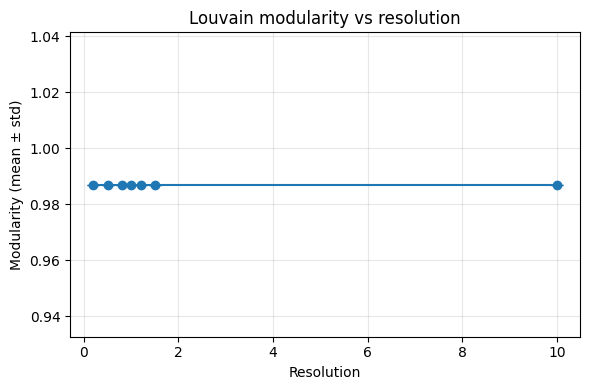

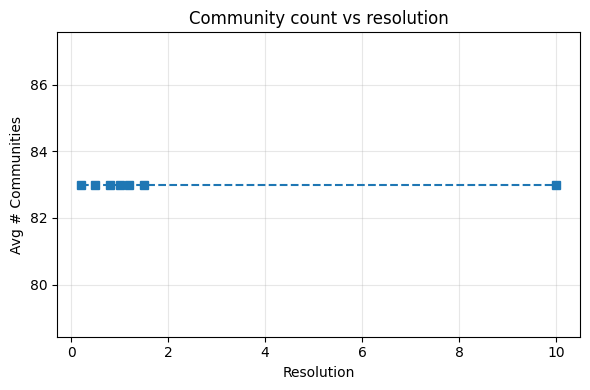

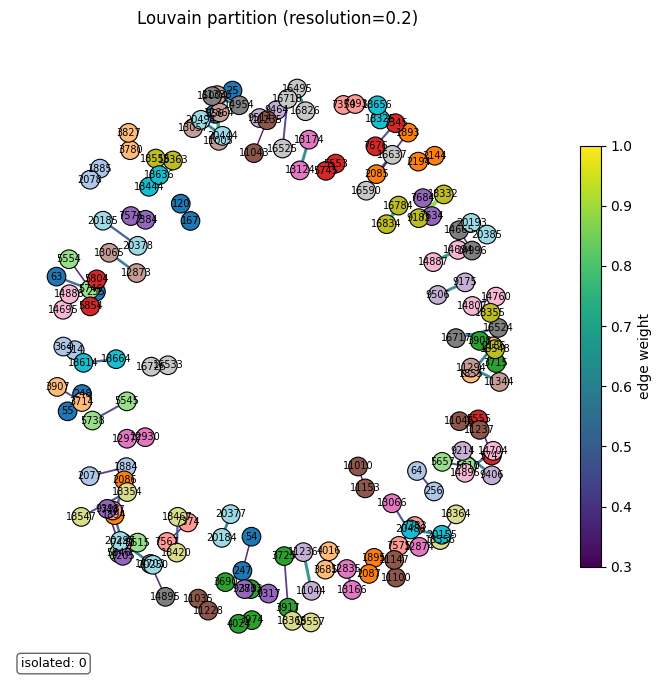


--- Export Louvain ---


ImportError: Missing optional dependency 'pytables'.  Use pip or conda to install pytables.

In [85]:
plot_perf = 1

def communities_to_labels(communities, node_order):
    """Convert list of sets to label array following provided node_order list."""
    labels = np.empty(len(node_order), dtype=int)
    idx_map = {node:i for i,node in enumerate(node_order)}
    for cid, comm in enumerate(communities):
        for node in comm:
            labels[idx_map[node]] = cid
    return labels

def run_louvain_resolution_scan(G, resolutions=(0.5, 0.8, 1.0, 1.2, 1.5), seeds=(0, 1, 2), weight='weight'):
    results = []
    for r in resolutions:
        for s in seeds:
            comms = louvain_communities(G, weight=weight, resolution=r, seed=s)
            mod = modularity(G, comms, weight=weight)
            results.append({'resolution': r, 'seed': s, 'modularity': mod, 'n_comm': len(comms), 'communities': comms})
    return results

def summarize_results(results):
    summary = {}
    for r in sorted({d['resolution'] for d in results}):
        mods = [d['modularity'] for d in results if d['resolution'] == r]
        n_comms = [d['n_comm'] for d in results if d['resolution'] == r]
        summary[r] = {'mod_mean': np.mean(mods), 'mod_std': np.std(mods), 'n_comm_mean': np.mean(n_comms)}
    return summary

def choose_best_partition(results):
    best = None
    for d in results:
        if best is None or d['modularity'] > best['modularity'] or (d['modularity'] == best['modularity'] and d['n_comm'] < best['n_comm']):
            best = d
    return best

def robustness_ari(results, resolution, G):
    parts = [d for d in results if d['resolution'] == resolution]
    node_order = sorted(G.nodes())
    label_arrays = [communities_to_labels(p['communities'], node_order) for p in parts]
    aris = []
    for (i, lab1), (j, lab2) in combinations(enumerate(label_arrays), 2):
        aris.append(adjusted_rand_score(lab1, lab2))
    return aris

if 'louvain' in methods:
    # Use actual node ordering with original IDs
    node_order = sorted(G.nodes())
    resolutions = (0.2, 0.5, 0.8, 1.0, 1.2, 1.5, 10.0)
    seeds = range(5)
    results = run_louvain_resolution_scan(G, resolutions=resolutions, seeds=seeds)
    summary = summarize_results(results)
    best = choose_best_partition(results)
    best_labels = communities_to_labels(best['communities'], node_order)
    best_aris = robustness_ari(results, best['resolution'], G)

    print(f"Best resolution: {best['resolution']}, modularity={best['modularity']:.4f}, communities={best['n_comm']}")
    print(f"Robustness (ARI mean ± std at best resolution): {np.mean(best_aris):.3f} ± {np.std(best_aris):.3f}")

    print("\nResolution  | Modularity(mean±std) | Avg #Communities")
    for r, vals in summary.items():
        print(f"{r:<10} | {vals['mod_mean']:.4f} ± {vals['mod_std']:.4f}    | {vals['n_comm_mean']:.2f}")

    if plot_perf:
        plt.figure(figsize=(6,4))
        plt.errorbar([r for r in summary.keys()], [v['mod_mean'] for v in summary.values()], yerr=[v['mod_std'] for v in summary.values()], fmt='o-', capsize=4)
        plt.xlabel('Resolution'); plt.ylabel('Modularity (mean ± std)'); plt.title('Louvain modularity vs resolution'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
        plt.figure(figsize=(6,4))
        plt.plot([r for r in summary.keys()], [v['n_comm_mean'] for v in summary.values()], 's--')
        plt.xlabel('Resolution'); plt.ylabel('Avg # Communities'); plt.title('Community count vs resolution'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    visualize_graph(G, best_labels, title=f"Louvain partition (resolution={best['resolution']})")

    nodes_ordered = sorted(G.nodes())
    
    print("\n--- Export Louvain ---")


In [86]:
if 'louvain' in methods:
    # Export Louvain clusters
    try:
        export_clusters(
            df=df, 
            labels=best_labels, 
            node_ids=nodes_ordered, 
            method_name='louvain', 
            subset_name=full_dataset
        )
    except Exception as e:
        print('Louvain export failed:', e)

Louvain export failed: id_list must be provided when labels cover only a subset of df IDs.


### Method 2 - Girvan–Newman

The Girvan–Newman algorithm detects communities by iteratively removing the most “between” edges (bridges between groups).

Workflow

1. Compute edge betweenness centrality for every edge:
   
   $b_e = \sum_{s \ne t} \frac{\sigma_{st}(e)}{\sigma_{st}}$ where $\sigma_{st}$ is the number of shortest paths between $s$ and $t$, and $\sigma_{st}(e)$ is the number of those paths that go through edge $e$.
2. Remove the edge(s) with the highest betweenness.
3. Recompute betweenness on the new graph and repeat. This yields a hierarchy of partitions with an increasing number of communities.
4. Score each partition by modularity and select the best level:
   
   $$Q = \frac{1}{2m} \sum_{i,j} \Big(A_{ij} - \frac{k_i k_j}{2m}\Big) \, \delta(c_i, c_j)$$
   where $A_{ij}$ is the adjacency, $k_i$ is the degree of node $i$, $m$ is the total number of edges, and $\delta(c_i,c_j)=1$ if nodes $i$ and $j$ are in the same community.

Notes
- We evaluate partitions using NetworkX’s modularity and pick the maximum-$Q$ split (no need to predefine the number of clusters).
- Our visualization reuses the earlier function: nodes are colored by community, edges by weight with a colorbar.


In [87]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community import modularity as nx_modularity

def run_gn_select_by_modularity(G, max_levels=20, weight='weight'):
    """Run Girvan-Newman and select best partition by modularity up to max_levels.
    
    Parameters
    ----------
    G : networkx.Graph
        max_levels : int
            Maximum number of levels to explore.
        weight : str or None
            Edge attribute for weights. If None, unweighted.
    Returns
    -------
    dict with keys:
        'best_partition' : tuple of sets
        'best_Q' : float
        'history' : list of dicts with keys 'level', 'n_comm', 'Q', 'communities'
    """
    H = G.to_undirected() if G.is_directed() else G
    comp_gen = girvan_newman(H)
    history = []
    best = None
    for level, communities in enumerate(comp_gen, start=1):
        comms = tuple(sorted((set(c) for c in communities), key=lambda s: min(s)))
        Q = nx_modularity(H, comms, weight=weight)
        record = {'level': level, 'n_comm': len(comms), 'Q': Q, 'communities': comms}
        history.append(record)
        if best is None or Q > best['Q'] or (Q == best['Q'] and len(comms) < best['n_comm']):
            best = record
        if level >= max_levels or len(comms) >= H.number_of_nodes():
            break
    return {'best_partition': best['communities'], 'best_Q': best['Q'], 'history': history}

if 'girvan_newman' in methods:
    gn_result = run_gn_select_by_modularity(G, max_levels=30, weight='weight')
    node_order = sorted(G.nodes())

    try:
        gn_best = gn_result['best_partition']
        gn_Q = gn_result['best_Q']
        gn_hist = gn_result['history']
        gn_best_labels = communities_to_labels(gn_best, node_order)
        print(f"GN best: Q={gn_Q:.4f}, communities={len(gn_best)}")
    except Exception as e:
        print('GN labeling failed:', e)

    if plot_perf:
        x = [h['n_comm'] for h in gn_hist]; y = [h['Q'] for h in gn_hist]
        plt.figure(figsize=(6,4))
        plt.plot(x, y, 'o-')
        plt.xlabel('# Communities'); plt.ylabel('Modularity Q'); plt.title('Girvan–Newman: modularity vs #communities')
        plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    visualize_graph(G, gn_best_labels, title=f"Girvan–Newman partition (Q={gn_Q:.3f}, k={len(gn_best)})")

    nodes_ordered = sorted(G.nodes())
    
    print("\n--- Export Girvan-Newman ---")
    export_clusters(
        df=df, 
        labels=gn_best_labels, 
        node_ids=nodes_ordered, 
        method_name='girvan_newman', 
        subset_name=full_dataset
    )

In [88]:
# Export Girvan–Newman clusters
try:
    export_clusters(df, gn_best_labels, method_name='girvan_newman')
except Exception as e:
    print('GN export failed:', e)

GN export failed: id_list must be provided when labels cover only a subset of df IDs.


In [89]:
df

,ID,sign,category,date,horoscope
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l..."
1,2,aries,general,20200618,People will understand and appreciate your des...
2,3,aries,general,20200619,You are very interested in technological break...
3,4,aries,general,20200620,Stress from overwork could have you feeling we...
4,5,aries,general,20200621,This is a good day to stand up for yourself an...
...,...,...,...,...,...
21954,21955,pisces,birthday,20210612,Celebrate in style on your birthday in prepara...
21955,21956,pisces,birthday,20210613,Imagine your life as if it was exactly the way...
21956,21957,pisces,birthday,20210614,"Fun, playfulness, and humor are easy to manife..."
21957,21958,pisces,birthday,20210615,"Your birthday brings you a fresh start, as you..."


### 3 - Model Comparison

### Comparison Output Explained
This table summarizes how similar the two community partitions (Louvain vs Girvan–Newman) are. Higher values mean closer agreement.

- Rand: fraction of node pairs on which the methods agree (same cluster or different clusters). Range [0, 1].
- Adjusted Rand (ARI): Rand index corrected for chance; 0 ≈ random, 1 = identical; can be negative if worse than random.
- Jaccard (pair-counting): among pairs co-assigned by at least one method, the fraction co-assigned by both. Range [0, 1].
- NMI: normalized mutual information between labelings; invariant to label permutations. 0 = independent, 1 = identical.

Below the table, the printed line shows how many communities each method found (useful context when interpreting the scores).

In [ ]:
# Compare Louvain vs Girvan–Newman partitions using clustering similarity metrics
from sklearn.metrics import rand_score, adjusted_rand_score, normalized_mutual_info_score

def jaccard_partition(y1, y2):
    """Pair-counting Jaccard similarity between two cluster labelings.
    Matches the definition used in exercise10 (counts co-assigned pairs)."""
    y1 = np.asarray(y1)
    y2 = np.asarray(y2)
    N = len(y1)
    S = 0  # pairs in same cluster in both
    D = 0  # pairs in different clusters in both
    for i in range(N):
        for j in range(i):
            same1 = (y1[i] == y1[j])
            same2 = (y2[i] == y2[j])
            if same1 and same2:
                S += 1
            if (not same1) and (not same2):
                D += 1
    total_pairs = N * (N - 1) / 2
    if total_pairs == D:
        return 0.0
    return S / (total_pairs - D)

# Ensure both label arrays exist and align in length
assert 'best_labels' in globals(), "Louvain labels 'best_labels' not found"
assert 'gn_best_labels' in globals(), "GN labels 'gn_best_labels' not found"
assert len(best_labels) == len(gn_best_labels), "Label arrays must have same length"

y_louvain = np.asarray(best_labels)
y_gn = np.asarray(gn_best_labels)

metrics = {
    'Rand': rand_score(y_louvain, y_gn),
    'Adjusted Rand (ARI)': adjusted_rand_score(y_louvain, y_gn),
    'Jaccard (pair-counting)': jaccard_partition(y_louvain, y_gn),
    'NMI': normalized_mutual_info_score(y_louvain, y_gn)
}
df_metrics = pd.DataFrame(metrics, index=['Louvain vs GN']).T
display(df_metrics)

# Optional: quick sanity display of community counts
print(f"Louvain communities: {len(np.unique(y_louvain))}, GN communities: {len(np.unique(y_gn))}")

AssertionError: Label arrays must have same length

**FINAL OUTPUT:** different clusters (subsets of predictions) with insights.
for each cluster, generate the following outputs:
- most common words
- most common signs
- most common topics
- a .csv file, subset of *horoscope_full.csv* with all predictions in the cluster.
- find the *'original prediction'*: the prediction that is the most similar to the other elements of the cluster, and (manually) check if the cluster makes sense